### Implementing Simple Chatbot using LangGraph

In [1]:
from typing_extensions import TypedDict
from langgraph.graph import StateGraph, START, END

## Reducers 
from typing import Annotated
from langgraph.graph.message import add_messages

In [2]:
class State(TypedDict):
    messages: Annotated[list, add_messages]

In [3]:
import os
from dotenv import load_dotenv
load_dotenv()

os.environ["OPENAI_API_KEY"]=os.getenv("OPENAI_API_KEY") # type: ignore
os.environ["GOOGLE_API_KEY"]=os.getenv("GOOGLE_API_KEY") # type: ignore

In [4]:
from langchain_openai import ChatOpenAI
llm = ChatOpenAI(model="gpt-4o")
llm.invoke("Hello")

AIMessage(content='Hello! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 9, 'prompt_tokens': 8, 'total_tokens': 17, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4o-2024-08-06', 'system_fingerprint': 'fp_64dfa806c7', 'id': 'chatcmpl-DCfV9fMzlGTXveODbxex6xQkMi9Ta', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019c8e2c-fe3a-7370-805b-ec0e4c6a2801-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 8, 'output_tokens': 9, 'total_tokens': 17, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [5]:
from langchain_groq import ChatGroq
llm_groq = ChatGroq(model="qwen/qwen3-32b")
llm_groq.invoke("Hi i'm Luis and I like to play soccer")

AIMessage(content="<think>\nOkay, the user introduced himself as Luis and mentioned he likes to play soccer. I should respond in a friendly and welcoming manner. Let me start by greeting him back and acknowledging his interest in soccer. Maybe ask him a question to keep the conversation going. I should check if there's any specific aspect of soccer he wants to talk about, like his favorite team, position, or maybe tips for improving. Keep it open-ended so he can elaborate. Also, make sure the tone is positive and encouraging. Let me put that together.\n</think>\n\nHi Luis! Nice to meet you. Soccer is an awesome sport—do you play it regularly? I'd love to hear more about your favorite part of the game or if you have a favorite team or position! 🏆⚽", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 159, 'prompt_tokens': 18, 'total_tokens': 177, 'completion_time': 0.332421227, 'completion_tokens_details': None, 'prompt_time': 0.000832394, 'prompt_tokens_detail

### We will start creating Nodes

In [6]:
def superbot(state: State):
    return {"messages":[llm_groq.invoke(state['messages'])]}

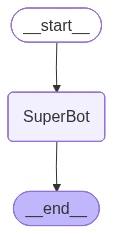

In [7]:
graph = StateGraph(State)

## node
graph.add_node("SuperBot", superbot)

## Edges
graph.add_edge(START, "SuperBot")
graph.add_edge("SuperBot", END)

graph_builder = graph.compile()

## Display
from IPython.display import Image, display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [8]:
## Invocation

graph_builder.invoke({"messages": "Hi my name is Luis and I like soccer"})

{'messages': [HumanMessage(content='Hi my name is Luis and I like soccer', additional_kwargs={}, response_metadata={}, id='9e0276a0-b4e6-4da5-84f7-07ba869d96a0'),
  AIMessage(content="<think>\nOkay, the user is Luis and he likes soccer. I need to respond in a friendly way. Let me start by greeting him. Then, maybe ask him how he got into soccer or what position he plays. I should keep the conversation open so he can share more. Also, maybe mention something about his favorite team or any favorite players. I want to make sure the response is engaging and not too long. Let me check if there are any common follow-up questions people usually ask when they mention liking sports. Yeah, asking about their experience, favorite moments, or future goals could be good. I'll structure the response with a greeting, a question about his soccer involvement, and maybe an invitation for him to share more. Keep it conversational and positive.\n</think>\n\nHello Luis! It's great to meet you. Soccer is su

### Streaming the responses

In [17]:
for event in graph_builder.stream({"messages": "Hello my name is Luis"}):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced himself as Luis. I should acknowledge his greeting and welcome him to the conversation. Let me make sure to keep it friendly and open-ended so he feels comfortable asking questions or sharing what's on his mind.\n\nI need to respond in a way that invites further interaction. Maybe ask how I can assist him today. Keep it simple and positive. Avoid using any technical jargon or complex language. Just a straightforward, welcoming message.\n</think>\n\nHello, Luis! Nice to meet you. How can I assist you today? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 113, 'prompt_tokens': 13, 'total_tokens': 126, 'completion_time': 0.242032614, 'completion_tokens_details': None, 'prompt_time': 0.001581625, 'prompt_tokens_details': None, 'queue_time': 0.172790577, 'total_time': 0.243614239}, 'model_name': 'qwen/qwen3-32b', 'system_fingerprint': 'fp_2bfcc54d36', 'service_tier': 'on_demand

In [15]:
for event in graph_builder.stream({"messages": "Hello my name is Luis"}, stream_mode="values"):
    print(event)

{'messages': [HumanMessage(content='Hello my name is Luis', additional_kwargs={}, response_metadata={}, id='f61e9da3-c77e-49f1-b2dd-9e1766820680')]}
{'messages': [HumanMessage(content='Hello my name is Luis', additional_kwargs={}, response_metadata={}, id='f61e9da3-c77e-49f1-b2dd-9e1766820680'), AIMessage(content="<think>\nOkay, the user said, Hello my name is Luis. Let me start by greeting him back and acknowledging his name. It's important to be friendly and open to encourage further conversation.\n\nI should ask how I can assist him to show I'm here to help. Maybe he has a question or needs information. I need to keep it simple and not too formal. Let me make sure the response is welcoming and easy to engage with.\n</think>\n\nHello, Luis! Nice to meet you. How can I assist you today? 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 110, 'prompt_tokens': 13, 'total_tokens': 123, 'completion_time': 0.217637441, 'completion_tokens_details': None, 'prom

In [16]:
for event in graph_builder.stream({"messages": "Hello my name is Luis"}, stream_mode="updates"):
    print(event)

{'SuperBot': {'messages': [AIMessage(content="<think>\nOkay, the user introduced themselves as Luis. I should respond warmly and show interest in getting to know them better. Let me make sure my greeting is friendly and welcoming.\n\nI need to ask them how I can assist. Maybe add an emoji to keep it approachable. Keep it simple and open-ended so they feel comfortable sharing what they need help with.\n\nDouble-check for any typos and ensure the tone is positive. Alright, that should do it.\n</think>\n\nHello Luis! 👋 Nice to meet you! How can I assist you today? Feel free to ask me anything or let me know if you'd like help with a specific task. 😊", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 135, 'prompt_tokens': 13, 'total_tokens': 148, 'completion_time': 0.319939422, 'completion_tokens_details': None, 'prompt_time': 0.000366754, 'prompt_tokens_details': None, 'queue_time': 0.171621769, 'total_time': 0.320306176}, 'model_name': 'qwen/qwen3-32b', 'syst